In [1]:
"""
Focus:
- L1 Regularization
- Feature Selection
- Coefficients becoming exactly ZERO
- Hyperparameter Tuning
- Comparison with Ridge
"""

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,cross_val_score,GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (Lasso,Ridge)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [2]:
# ============================================================
# STEP 1 : DATA UNDERSTANDING
# ============================================================

housing = fetch_california_housing()
df = pd.DataFrame(housing.data,columns=housing.feature_names)
df["Target"] = housing.target
print(df.head())
print(df.shape)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
(20640, 9)


In [5]:
# ============================================================
# STEP 2 : EDA
# ============================================================

print(df.isnull().sum())
print()
print("no of duplicates are: ", df.duplicated().sum())


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

no of duplicates are:  0


In [6]:
# ============================================================
# STEP 3 : TRAIN / VALIDATION / TEST
# ============================================================

X = df.drop("Target", axis=1)
y = df["Target"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=0.15,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,test_size=0.1765,random_state=42)

In [7]:
# ============================================================
# STEP 4 : PREPROCESSING
# ============================================================

# Scaling is mandatory for Lasso.
# L1 penalty is affected by feature magnitude.

pipe = Pipeline([("scaler", StandardScaler()),("model", Lasso(alpha=1.0,random_state=42,max_iter=10000))])

In [8]:
# ============================================================
# STEP 5 : BASELINE MODEL
# ============================================================

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True


In [9]:
# ============================================================
# STEP 6 : METRICS for prediction against validation data with base model
# ============================================================

y_pred = pipe.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Baseline MAE :", mae)
print("Baseline RMSE:", rmse)
print("Baseline R2  :", r2)

Baseline MAE : 0.9075818382139841
Baseline RMSE: 1.157057956553808
Baseline R2  : -0.0007062036549339012


In [10]:
# ============================================================
# STEP 7 : CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(pipe,X_train,y_train,cv=5,scoring="r2",n_jobs=-1)
print("CV Scores:", cv_scores)
print("CV Mean :", cv_scores.mean())
print("CV Std  :", cv_scores.std())

CV Scores: [-5.34562028e-04 -4.37771618e-05 -1.63367860e-05 -3.63145171e-04
 -2.03736617e-04]
CV Mean : -0.00023231155297662732
CV Std  : 0.00019569344860459296


In [11]:
# ============================================================
# STEP 8 : HYPERPARAMETER TUNING
# ============================================================

# alpha controls strength of L1 penalty.
# Larger alpha
# -> More coefficients become zero.

param_grid = {"model__alpha":[0.0001,0.001,0.01,0.1,1,10]}
grid = GridSearchCV(pipe,param_grid,cv=5,scoring="r2",n_jobs=-1)
grid.fit(X_train, y_train)
print("best params: ", grid.best_params_)
print("best score: ", grid.best_score_)
best_model = grid.best_estimator_
print(best_model)

best params:  {'model__alpha': 0.001}
best score:  0.6027572656465203
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', Lasso(alpha=0.001, max_iter=10000, random_state=42))])


In [12]:
# ============================================================
# STEP 9 : VALIDATION check with best model
# ============================================================

y_best = best_model.predict(X_val)
val_r2 = r2_score(y_val, y_best)
print("Validation R2:", val_r2)

Validation R2: 0.6144158836841758


In [13]:
# ============================================================
# STEP 10 : TRAIN VS VALIDATION with best model
# ============================================================

y_train_best = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_best)
print("Train R2:", train_r2)
print("Val R2  :", val_r2)

Train R2: 0.6075442198278167
Val R2  : 0.6144158836841758



Lasso Coefficients
      Feature  Coefficient
0      MedInc     0.832521
1    HouseAge     0.117960
2    AveRooms    -0.283506
3   AveBedrms     0.318869
4  Population    -0.003580
5    AveOccup    -0.045192
6    Latitude    -0.881033
7   Longitude    -0.850780


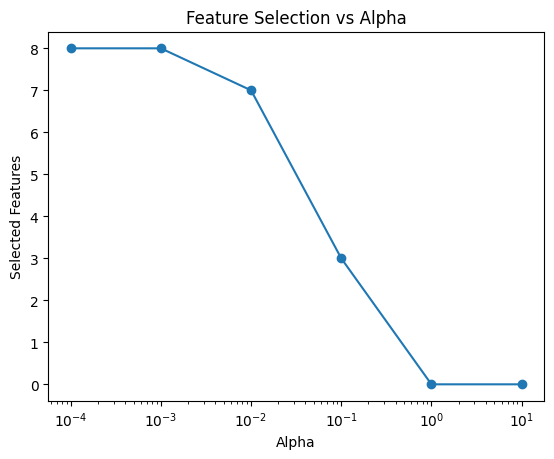

      Feature     Ridge     Lasso
0      MedInc  0.838016  0.832521
1    HouseAge  0.117158  0.117960
2    AveRooms -0.298594 -0.283506
3   AveBedrms  0.333815  0.318869
4  Population -0.004936 -0.003580
5    AveOccup -0.046184 -0.045192
6    Latitude -0.890486 -0.881033
7   Longitude -0.860932 -0.850780


In [15]:
# ============================================================
# STEP 11 : LASSO SPECIFIC ANALYSIS
# ============================================================

lasso_model = best_model.named_steps["model"]
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": lasso_model.coef_})

print("\nLasso Coefficients")
print(coef_df)

# ------------------------------------------------------------
# FEATURE SELECTION
# ------------------------------------------------------------

selected_features = coef_df[coef_df["Coefficient"] != 0]
removed_features = coef_df[coef_df["Coefficient"] == 0]

# Ridge -> shrinks coefficients
# Lasso -> can make coefficients EXACTLY ZERO
# Therefore:
# Lasso performs feature selection.

# ------------------------------------------------------------
# Number of Features vs Alpha
# ------------------------------------------------------------

alphas = [0.0001,0.001,0.01,0.1,1,10]
feature_counts = []

for alpha in alphas:
    temp = Pipeline([("scaler", StandardScaler()),("model", Lasso(alpha=alpha,random_state=42,max_iter=10000))])

    temp.fit(X_train, y_train)
    coeffs = temp.named_steps["model"].coef_
    feature_counts.append(np.sum(coeffs != 0))

plt.plot(alphas, feature_counts, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Selected Features")
plt.title("Feature Selection vs Alpha")
plt.show()

# ------------------------------------------------------------
# RIDGE VS LASSO
# ------------------------------------------------------------

ridge_pipe = Pipeline([("scaler", StandardScaler()),("model", Ridge(alpha=1))])
ridge_pipe.fit(X_train, y_train)
comparison = pd.DataFrame({"Feature": X.columns,"Ridge": ridge_pipe.named_steps["model"].coef_,"Lasso": lasso_model.coef_})

print(comparison)

In [16]:
# ============================================================
# STEP 12 : FINAL MODEL FREEZE
# ============================================================

final_model = best_model

In [18]:
# ============================================================
# STEP 13 : TEST EVALUATION
# ============================================================

test_pred = final_model.predict(X_test)
print("Test MAE :",mean_absolute_error(y_test, test_pred))
print("Test RMSE:",np.sqrt(mean_squared_error(y_test, test_pred)))
test_r2 = r2_score(y_test, test_pred)
print(test_r2)

Test MAE : 0.5354169500040759
Test RMSE: 0.7327732737499764
0.5902682443237767


In [19]:
# ============================================================
# STEP 14 : INTERPRETATION
# ============================================================

print("\nFinal Coefficients")
print(coef_df.sort_values(by="Coefficient",ascending=False))


Final Coefficients
      Feature  Coefficient
0      MedInc     0.832521
3   AveBedrms     0.318869
1    HouseAge     0.117960
4  Population    -0.003580
5    AveOccup    -0.045192
2    AveRooms    -0.283506
7   Longitude    -0.850780
6    Latitude    -0.881033


In [20]:
# ============================================================
# STEP 15 : DEPLOYMENT READINESS
# ============================================================

print("CV Mean:", cv_scores.mean())
print("Validation R2:", val_r2)
print("Test R2:", test_r2)


CV Mean: -0.00023231155297662732
Validation R2: 0.6144158836841758
Test R2: 0.5902682443237767


# ============================================================
# INTERVIEW QUESTIONS
# ============================================================

"""
1. Why was Lasso introduced?
2. What is L1 Regularization?
3. Lasso cost function?
4. What does alpha control?
5. Difference between Ridge and Lasso?
6. Can Ridge perform feature selection?
7. Why can Lasso perform feature selection?
8. What happens when alpha increases?
9. Why is scaling important?
10. What is sparse model?
11. When should you use Lasso?
12. What if important features are correlated?
13. Why does Lasso sometimes remove useful features?
14. Difference between Lasso and ElasticNet?
15. Explain coefficient shrinkage.
"""
